In [23]:
import os
import glob
import sys
import pandas as pd
import numpy as np

INPUT_FOLDER = "Simulated_Waveforms"

# Recursively find all CSV files in the Simulated_Waveforms directory
search_path = os.path.join(INPUT_FOLDER, '*.csv')
channel_files = glob.glob(search_path)

if not channel_files:
    print(f"No channel files found in {INPUT_FOLDER}")
    sys.exit()
    
print(f"Loading {len(channel_files)} channel files into memory...")

# dictionary containing the time and signal data for each channel
# format: {filename: pd.DataFrame, shape = (N, 3), columns = ['time', 'signal', 'PD number']}
channel_dataframes = {}
for filepath in channel_files:
    filename = os.path.basename(filepath)
    try:
        # Load the CSV file without headers
        df = pd.read_csv(filepath, header=None)
        channel_dataframes[filename] = df
        print(f"  Loaded {filename}")
    except Exception as e:
        print(f"  Error loading {filename}: {e}")
        
if not channel_dataframes:
    print("No dataframes loaded. Exiting.")
    sys.exit()

Loading 4 channel files into memory...
  Loaded Ch1.csv
  Loaded Ch2.csv
  Loaded Ch3.csv
  Loaded Ch4.csv


In [24]:
import scipy.signal as signal
import numpy as np

def calculate_lag(env1, env2):
    # inputs are two numpy 1D arrays, and the sampling frequency
    # env 1 is sensor1, env2 is sensor2,3,4

    # value of first index in correlation array is the correlation when env2 is moved to the leftmost position
    correlation = signal.correlate(env1, env2, mode='full')
    
    # first index in lags is the negative length of env2 + 1 (corresponding to env2 being moved to the leftmost position)
    lags = signal.correlation_lags(env1.size, env2.size, mode='full')
    
    # Find lag with maximum correlation (restricted to middle 2000 samples)
    mid = len(correlation) // 2
    start_idx = max(0, mid - 1000)
    end_idx = min(len(correlation), mid + 1000)
    lag = lags[start_idx:end_idx][np.argmax(correlation[start_idx:end_idx])]

    '''
    positive tdoa means env2 is to the right of env1
    i.e. signal takes longer time to reach sensor 2,3,4 than 1
    thus positive tdoa means env2 is moved left, meaning negative lag
    '''

    return lag


In [25]:
import pandas as pd
import Envelope_Analysis as EA
import numpy as np
from scipy.optimize import least_squares
import scipy.signal as signal
import ModSecant_PDLocalisation as ModSec

INDICES_FILE = "Waveform_Analysis.csv"
SAMPLING_FREQ = 5e9
C_VELOCITY = 3e8 # Speed of light in m/s (adjust if in different medium)

# Sensor coordinates from Generate_Waveforms.ipynb
sensors = np.array([
    [1.0, 3.0, 1.4], # S1 (Reference Channel 1)
    [1.0, 5.0, 1.8], # S2
    [1.0, 7.0, 1.4], # S3
    [1.0, 9.0, 1.8]  # S4
])

PD1_coords = np.array([1.2, 2.3, 3.1])
PD2_coords = np.array([2.9, 6.3, 5.4])
PD3_coords = np.array([4.5, 7.8, 6.2])
PD4_coords = np.array([6.1, 1.7, 3.5])
PD5_coords = np.array([7.8, 1.2, 4.9])
PD6_coords = np.array([9.2, 3.5, 2.8])

PD_coords = np.array([
    PD1_coords,
    PD2_coords,
    PD3_coords,
    PD4_coords,
    PD5_coords,
    PD6_coords
])

TDOA_results = []

indices_df = pd.read_csv(INDICES_FILE)
    
if indices_df.empty:
    print("No isolated waveforms found in indices file.")
    

# Ensure needed columns exist
if not all(col in indices_df.columns for col in ['input filename', 'PD number','start idx', 'end idx', 'Grouping_Envelope_Analysis']):
    print(f"Error: Input CSV must contain ['input filename', 'PD number','start idx', 'end idx', 'Grouping_Envelope_Analysis'] columns.")
    

groups = indices_df[indices_df['Grouping_Envelope_Analysis'] > 0]['Grouping_Envelope_Analysis'].unique()

warning = ''
for group_id in sorted(groups):
    df_onegroup = indices_df[indices_df['Grouping_Envelope_Analysis'] == group_id]
    df_onegroup = df_onegroup[['input filename', 'PD number','start idx', 'end idx', 'Grouping_Envelope_Analysis']]
    valuecounts = df_onegroup['input filename'].value_counts()

    if valuecounts.max() > 1:
        warning = "One or more groups has multiple waveforms for the same channel."
    if not all(df_onegroup['input filename'].str.contains(filename).any() for filename in ['Ch1', 'Ch2', 'Ch3', 'Ch4']):
        warning = "One or more groups is missing at least one waveform from at least one channel."
        continue

    df_onegroup = df_onegroup.drop_duplicates(subset=['input filename'], keep='first')

    if (df_onegroup['PD number'].unique().size == 1) & (df_onegroup['PD number'].iloc[0] > 0):
        pd_number = df_onegroup['PD number'].iloc[0]
    else:
        pd_number = -1

    first_signal = df_onegroup[df_onegroup['input filename'].str.contains('Ch1')].iloc[0]
    input_filename = first_signal['input filename']
    start_idx = first_signal['start idx']
    end_idx = first_signal['end idx']
    start_time_1 = channel_dataframes[input_filename].iloc[start_idx,0]
    
    raw_sig1 = EA.load_waveform(input_filename, start_idx, end_idx, channel_dataframes)
    env1 = EA.process_envelope(raw_sig1, sigma_samples=12)

    tdoa = [0,0,0]
    for index, next_signal in df_onegroup.iterrows():
        if 'ch1' in next_signal['input filename'].lower():
            continue
        
        input_filename = next_signal['input filename']
        start_idx = next_signal['start idx']
        end_idx = next_signal['end idx']
    
        raw_sig2 = EA.load_waveform(input_filename, start_idx, end_idx, channel_dataframes)
        env2 = EA.process_envelope(raw_sig2, sigma_samples=12)
        start_time_2 = channel_dataframes[input_filename].iloc[start_idx,0]

        if 'ch2' in next_signal['input filename'].lower():
            lag = calculate_lag(env1, env2)
            total_lag = start_time_2 - start_time_1 - lag/SAMPLING_FREQ
            tdoa[0] = total_lag
        elif 'ch3' in next_signal['input filename'].lower():
            lag = calculate_lag(env1, env2)
            total_lag = start_time_2 - start_time_1 - lag/SAMPLING_FREQ
            tdoa[1] = total_lag
        elif 'ch4' in next_signal['input filename'].lower():
            lag = calculate_lag(env1, env2)
            total_lag = start_time_2 - start_time_1 - lag/SAMPLING_FREQ
            tdoa[2] = total_lag
    
    # estimated_pos = ModSec.modsecant(sensors[0],sensors[1],sensors[2],sensors[3],tdoa[0],tdoa[1],tdoa[2])
            
    TDOA_results.append({
        'Group': group_id,
        'TDOA_21': tdoa[0],
        'TDOA_31': tdoa[1],
        'TDOA_41': tdoa[2],
        'Actual_X': PD_coords[int(pd_number)-1][0] if pd_number > 0 else -1000,
        'Actual_Y': PD_coords[int(pd_number)-1][1] if pd_number > 0 else -1000,
        'Actual_Z': PD_coords[int(pd_number)-1][2] if pd_number > 0 else -1000,
        # 'Est_X': estimated_pos[0],
        # 'Est_Y': estimated_pos[1],
        # 'Est_Z': estimated_pos[2]
    })

if TDOA_results:
    final_df = pd.DataFrame(TDOA_results)
    print("\nFinal Localization Results:")
    display(final_df)   

TDOA_results_df = pd.DataFrame(TDOA_results)
TDOA_results_df.to_csv('TDOA_Results.csv', index=False)



Final Localization Results:


,Group,TDOA_21,TDOA_31,TDOA_41,Actual_X,Actual_Y,Actual_Z
0,1,3.800000e-09,1.060000e-08,1.660000e-08,1.2,2.3,3.1
1,2,4.600000e-09,5.400000e-09,6.200000e-09,4.5,7.8,6.2
2,3,2.200000e-09,6.600000e-09,1.140000e-08,6.1,1.7,3.5
3,4,4.600000e-09,5.600000e-09,6.400000e-09,4.5,7.8,6.2
4,5,3.800000e-09,1.060000e-08,1.660000e-08,1.2,2.3,3.1
5,6,4.200000e-09,3.400000e-09,2.200000e-09,7.8,1.2,4.9
6,7,4.200000e-09,3.600000e-09,2.200000e-09,2.9,6.3,5.4
7,8,3.800000e-09,1.040000e-08,1.660000e-08,1.2,2.3,3.1
8,9,2.000000e-10,2.200000e-09,5.200000e-09,9.2,3.5,2.8
9,10,2.000000e-09,6.600000e-09,1.120000e-08,6.1,1.7,3.5


# Printing out the TDOA results for MATLAB PSO

In [26]:
# Iterate through the DataFrame and print specified columns comma+space separated
for _, row in TDOA_results_df.iterrows():
    print(f"{row['Actual_X']}, {row['Actual_Y']}, {row['Actual_Z']}, {row['TDOA_21']}, {row['TDOA_31']}, {row['TDOA_41']}")

1.2, 2.3, 3.1, 3.7999999999994236e-09, 1.060000000000128e-08, 1.659999999999969e-08
4.5, 7.8, 6.2, 4.600000000000559e-09, 5.40000000000012e-09, 6.199999999999802e-09
6.1, 1.7, 3.5, 2.200000000001436e-09, 6.600000000000919e-09, 1.1400000000001718e-08
4.5, 7.8, 6.2, 4.599999999999922e-09, 5.600000000001676e-09, 6.4000000000000424e-09
1.2, 2.3, 3.1, 3.800000000001118e-09, 1.0600000000003352e-08, 1.659999999999969e-08
7.8, 1.2, 4.9, 4.200000000004385e-09, 3.4000000000017965e-09, 2.199999999997892e-09
2.9, 6.3, 5.4, 4.1999999999952185e-09, 3.6000000000074554e-09, 2.2000000000043856e-09
1.2, 2.3, 3.1, 3.799999999995657e-09, 1.0399999999997891e-08, 1.659999999999925e-08
9.2, 3.5, 2.8, 2.0000000001399107e-10, 2.2000000000183765e-09, 5.199999999998288e-09
6.1, 1.7, 3.5, 2.0000000000043854e-09, 6.600000000000919e-09, 1.1200000000011444e-08
9.2, 3.5, 2.8, 2e-10, 2.4000000000052625e-09, 5.400000000012279e-09
1.2, 2.3, 3.1, 3.999999999995657e-09, 1.0599999999984339e-08, 1.6599999999986136e-08
6.1, 

In [27]:
df = pd.read_csv('converted_data_envelope_analysis.csv', header=None)
TDOA_results_df[['PSO_X','PSO_Y','PSO_Z']] = df.iloc[:,3:6].values
TDOA_results_df[['PSO_Percentage_Error', 'PSO_Euclidean_Error']] = df.iloc[:,0:2].values

TDOA_results_df.to_csv('TDOA_Results.csv', index=False)

In [28]:
from sklearn.cluster import DBSCAN

epsilon = 1
min_samples = 2

X = TDOA_results_df[['PSO_X', 'PSO_Y', 'PSO_Z']].values

dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)

clusters = dbscan.fit_predict(X)

TDOA_results_df['cluster (PSO -> DBSCAN)'] = clusters

TDOA_results_df.to_csv('TDOA_Results.csv', index=False)

Generating 3D Cluster Plot...


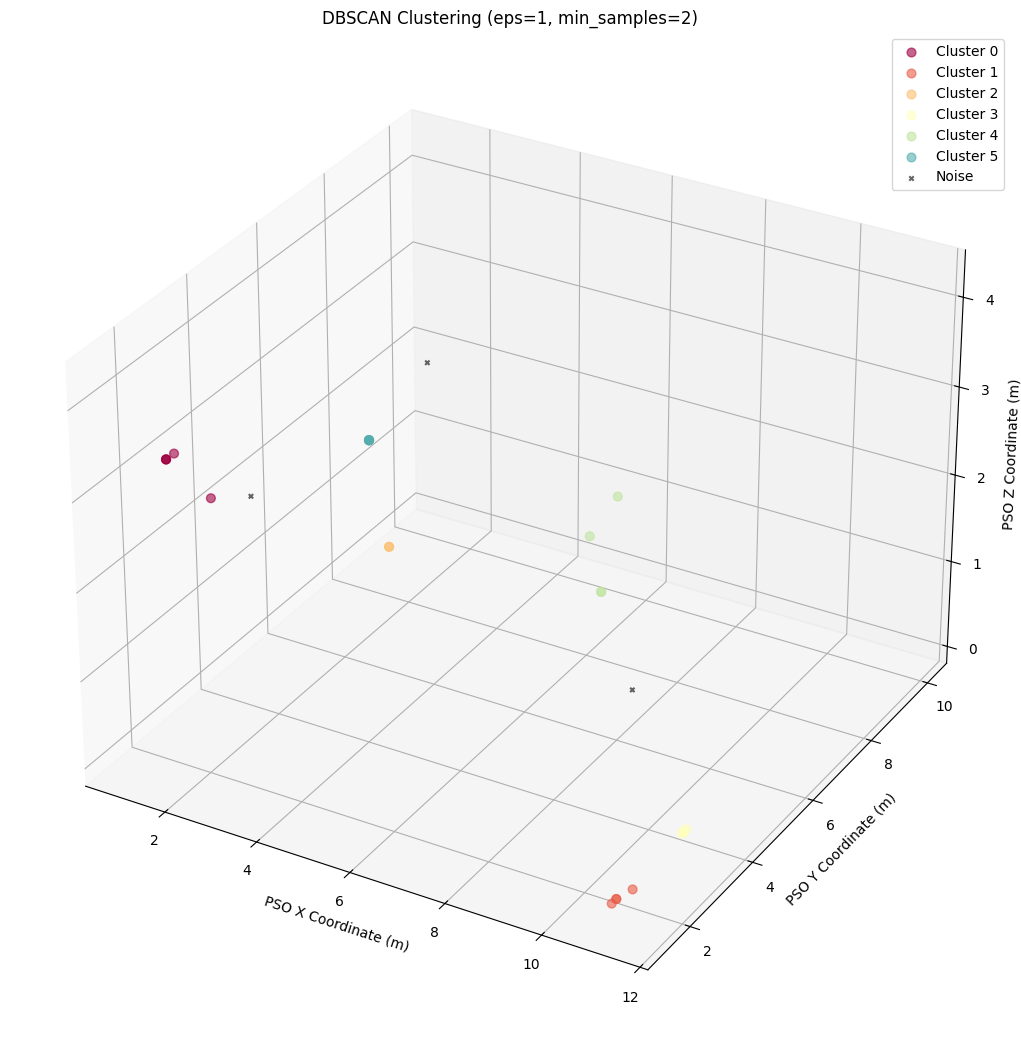

In [29]:
import matplotlib.pyplot as plt

print("Generating 3D Cluster Plot...")
    
fig = plt.figure(figsize=(15, 13))
ax = fig.add_subplot(111, projection='3d')

# Get unique labels
unique_labels = set(clusters)

# Define colors (using a colormap)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise, similar to unclassified points in paper figures
        col = [0, 0, 0, 1]
        label = "Noise"
        marker = 'x'
        size = 10
    else:
        label = f"Cluster {k}"
        marker = 'o'
        size = 40

    # Select data for this luster
    class_member_mask = (clusters == k)
    xyz = X[class_member_mask]
    
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], 
                c=[col], s=size, label=label, marker=marker, alpha=0.6)

ax.set_xlabel('PSO X Coordinate (m)')
ax.set_ylabel('PSO Y Coordinate (m)')
ax.set_zlabel('PSO Z Coordinate (m)')
ax.set_title(f'DBSCAN Clustering (eps={epsilon}, min_samples={min_samples})')
ax.legend()

plt.show()

In [30]:
# Calculate the mean PSO_X, PSO_Y, and PSO_Z for each cluster
pso_cluster_means = TDOA_results_df.groupby('cluster (PSO -> DBSCAN)')[['PSO_X', 'PSO_Y', 'PSO_Z']].mean()

# Display the results
print(pso_cluster_means)

                           PSO_X     PSO_Y     PSO_Z
cluster (PSO -> DBSCAN)                             
-1                        4.7000  5.153333  2.186667
 0                        1.2560  2.284000  3.066000
 1                       11.1000  1.407500  0.155000
 2                        6.1500  1.760000  3.090000
 3                       11.0000  3.575000  0.100000
 4                        9.3325  3.475000  2.952500
 5                        5.8500  1.650000  4.220000


In [31]:
PD1_coords = np.array([1.2, 2.3, 3.1])
PD2_coords = np.array([2.9, 6.3, 5.4])
PD3_coords = np.array([4.5, 7.8, 6.2])
PD4_coords = np.array([6.1, 1.7, 3.5])
PD5_coords = np.array([7.8, 1.2, 4.9])
PD6_coords = np.array([9.2, 3.5, 2.8])

def calculate_distance(arry1, arry2):
    return np.linalg.norm(arry1 - arry2)

data = np.array([[1.2560,2.2840,3.0660,1.2,2.3,3.1],
[11.1000,1.4075,0.1550,2.9,6.3,5.4],
[6.1500,1.7600,3.0900,6.1,1.7,3.5],
[11.0000,3.5750,0.1000,4.5,7.8,6.2],
[9.3325,3.4750,2.9525,9.2,3.5,2.8],
[5.8500,1.6500,4.2200,7.8,1.2,4.9]])

x = data[:, :3]
y = data[:, 3:]

sum = 0
for i in range(len(x)):
    sum += calculate_distance(x[i], y[i])
    print(calculate_distance(x[i], y[i]))

print(sum/len(x))



0.06743886120034963
10.894337118429924
0.4173727350941844
9.864614792276484
0.20356202985822325
2.113622482847872
3.926824669951173


In [32]:
'''
import PSO as pso
# PSO
temp1 = TDOA_results_df[['Actual_X', 'Actual_Y', 'Actual_Z']].to_numpy()
temp2 = TDOA_results_df[['TDOA_21', 'TDOA_31', 'TDOA_41']].to_numpy()
data_predict = np.concatenate((temp1, temp2), axis=1)
results = pso.pso_algorithm(data_predict)
'''

"\nimport PSO as pso\n# PSO\ntemp1 = TDOA_results_df[['Actual_X', 'Actual_Y', 'Actual_Z']].to_numpy()\ntemp2 = TDOA_results_df[['TDOA_21', 'TDOA_31', 'TDOA_41']].to_numpy()\ndata_predict = np.concatenate((temp1, temp2), axis=1)\nresults = pso.pso_algorithm(data_predict)\n"

In [33]:
'''
pso_results_df = pd.DataFrame(results)


pso_coordinates_df = pd.DataFrame(pso_results_df['estimated_location'].to_list(), columns=['PSO_X', 'PSO_Y', 'PSO_Z'])

pso_coordinates_df['PSO_oercentage_error'] = pso_results_df['percentage_error']
pso_coordinates_df['PSO_euclidean_distance'] = pso_results_df['euclidean_distance']

TDOA_results_df = pd.concat([TDOA_results_df, pso_coordinates_df], axis=1)

TDOA_results_df.to_csv('TDOA_Results.csv', index=False)
'''




"\npso_results_df = pd.DataFrame(results)\n\n\npso_coordinates_df = pd.DataFrame(pso_results_df['estimated_location'].to_list(), columns=['PSO_X', 'PSO_Y', 'PSO_Z'])\n\npso_coordinates_df['PSO_oercentage_error'] = pso_results_df['percentage_error']\npso_coordinates_df['PSO_euclidean_distance'] = pso_results_df['euclidean_distance']\n\nTDOA_results_df = pd.concat([TDOA_results_df, pso_coordinates_df], axis=1)\n\nTDOA_results_df.to_csv('TDOA_Results.csv', index=False)\n"

In [40]:
from sklearn.cluster import DBSCAN

epsilon = 1.5e-9
min_samples = 2

X = TDOA_results_df[['TDOA_21', 'TDOA_31', 'TDOA_41']].values

dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)

clusters = dbscan.fit_predict(X)

TDOA_results_df['cluster (DBSCAN -> PSO)'] = clusters

TDOA_results_df.to_csv('TDOA_Results.csv', index=False)


Generating 3D Cluster Plot...


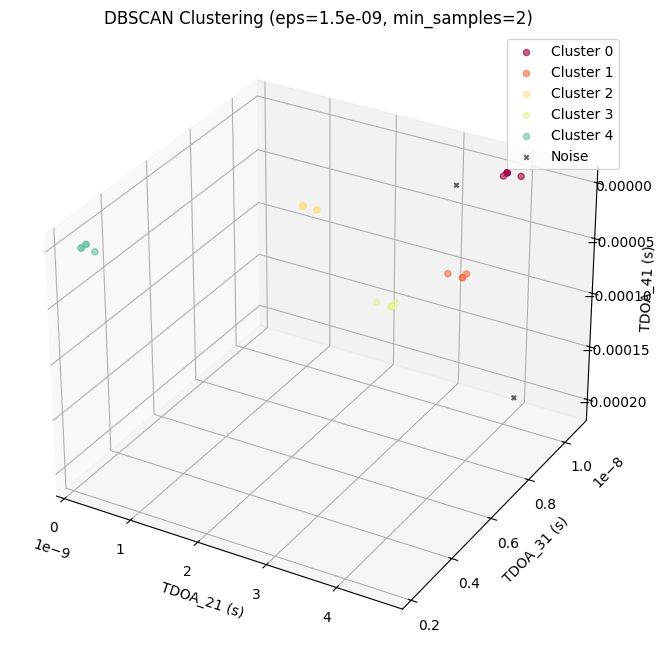

In [36]:
import matplotlib.pyplot as plt

print("Generating 3D Cluster Plot...")
    
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Get unique labels
unique_labels = set(clusters)

# Define colors (using a colormap)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise, similar to unclassified points in paper figures
        col = [0, 0, 0, 1]
        label = "Noise"
        marker = 'x'
        size = 10
    else:
        label = f"Cluster {k}"
        marker = 'o'
        size = 20

    # Select data for this cluster
    class_member_mask = (clusters == k)
    xyz = X[class_member_mask]
    
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], 
                c=[col], s=size, label=label, marker=marker, alpha=0.6)

ax.set_xlabel('TDOA_21 (s)')
ax.set_ylabel('TDOA_31 (s)')
ax.set_zlabel('TDOA_41 (s)')
ax.set_title(f'DBSCAN Clustering (eps={epsilon}, min_samples={min_samples})')
ax.legend()

plt.show()

In [41]:
# Calculate mean TDOA and Actual coordinates for each cluster
cluster_means = TDOA_results_df[TDOA_results_df['cluster (DBSCAN -> PSO)'] != -1].groupby('cluster (DBSCAN -> PSO)').mean()

# Prepare data for PSO: Actual_X, Actual_Y, Actual_Z, TDOA_21, TDOA_31, TDOA_41
# The columns in cluster_means will be Group, TDOA_21, TDOA_31, TDOA_41, Actual_X, Actual_Y, Actual_Z
pso_input_data = cluster_means[['Actual_X', 'Actual_Y', 'Actual_Z', 'TDOA_21', 'TDOA_31', 'TDOA_41']].to_numpy()

print(f"Running PSO for {len(cluster_means)} clusters...")
import PSO as pso
cluster_pso_results = pso.pso_algorithm(pso_input_data)

# Convert results to DataFrame for display
cluster_pso_df = pd.DataFrame(cluster_pso_results)
# Add cluster ID back
cluster_pso_df['cluster'] = cluster_means.index.tolist()

print("\nPSO Results for Cluster Means:")
print(cluster_pso_df[['cluster', 'estimated_location', 'true_location', 'euclidean_distance', 'percentage_error']])


Running PSO for 5 clusters...
Convergence reached after 1134 iterations.

Results for dataset 1:
Estimated location: [np.float64(1.08), np.float64(2.26), np.float64(3.14)]
True location: [np.float64(1.2), np.float64(2.3), np.float64(3.1)]
Euclidean distance error: 0.134
Percentage error: 3.3%
Computation time: 33.26 seconds
Convergence reached after 1027 iterations.

Results for dataset 2:
Estimated location: [np.float64(11.0), np.float64(1.43), np.float64(0.1)]
True location: [np.float64(5.32), np.float64(6.15), np.float64(5.88)]
Euclidean distance error: 9.373
Percentage error: 84.46%
Computation time: 28.98 seconds
Convergence reached after 1111 iterations.

Results for dataset 3:
Estimated location: [np.float64(5.65), np.float64(2.34), np.float64(1.5)]
True location: [np.float64(6.1), np.float64(1.7), np.float64(3.5)]
Euclidean distance error: 2.144
Percentage error: 36.2%
Computation time: 32.48 seconds
Convergence reached after 1085 iterations.

Results for dataset 4:
Estimated l

In [73]:
PD1_coords = np.array([1.2, 2.3, 3.1])
PD2_coords = np.array([2.9, 6.3, 5.4])
PD3_coords = np.array([4.5, 7.8, 6.2])
PD4_coords = np.array([6.1, 1.7, 3.5])
PD5_coords = np.array([7.8, 1.2, 4.9])
PD6_coords = np.array([9.2, 3.5, 2.8])

def calculate_distance(arry1, arry2):
    return np.linalg.norm(arry1 - arry2)

data = np.array([[1.08,2.26,3.14,1.2,2.3,3.1],
[11.0,1.43,0.1,2.9,6.3,5.4],
[5.65,2.34,1.5,6.1,1.7,3.5],
[11.0,3.52,1.04,7.8,1.2,4.9],
[9.07,3.64,1.68,9.2,3.5,2.8]
])

x = data[:, :3]
y = data[:, 3:]
'''
print(calculate_distance(np.array([11,1.43,0.1]), np.array([2.9,6.3,5.4])))
print(calculate_distance(np.array([11,1.43,0.1]), np.array([4.5, 7.8, 6.2])))
print(calculate_distance(np.array([11,1.43,0.1]), np.array([7.8, 1.2, 4.9])))

print(calculate_distance(np.array([11,3.52,1.04]), np.array([2.9,6.3,5.4])))
print(calculate_distance(np.array([11,3.52,1.04]), np.array([4.5, 7.8, 6.2])))
print(calculate_distance(np.array([11,3.52,1.04]), np.array([7.8, 1.2, 4.9])))


'''
sum = 0

for i in range(len(x)):
    sum += calculate_distance(x[i], y[i])
    print(calculate_distance(x[i], y[i]))

print(sum/len(x))



0.1326649916142159
10.83590789920254
2.14758003343298
5.524671935961448
1.1361778029868386
3.9554005326396053


# Section 2:
# TDOA and localization for results of PCA

In [74]:
import pandas as pd
import Envelope_Analysis as EA
import numpy as np
from scipy.optimize import least_squares
import scipy.signal as signal
import ModSecant_PDLocalisation as ModSec

INDICES_FILE = "Waveform_Analysis.csv"
SAMPLING_FREQ = 5e9
C_VELOCITY = 3e8 # Speed of light in m/s (adjust if in different medium)

# Sensor coordinates from Generate_Waveforms.ipynb
sensors = np.array([
    [1.0, 3.0, 1.4], # S1 (Reference Channel 1)
    [1.0, 5.0, 1.8], # S2
    [1.0, 7.0, 1.4], # S3
    [1.0, 9.0, 1.8]  # S4
])

PD1_coords = np.array([1.2, 2.3, 3.1])
PD2_coords = np.array([2.9, 6.3, 5.4])
PD3_coords = np.array([4.5, 7.8, 6.2])
PD4_coords = np.array([6.1, 1.7, 3.5])
PD5_coords = np.array([7.8, 1.2, 4.9])
PD6_coords = np.array([9.2, 3.5, 2.8])

PD_coords = np.array([
    PD1_coords,
    PD2_coords,
    PD3_coords,
    PD4_coords,
    PD5_coords,
    PD6_coords
])

TDOA_results = []

indices_df = pd.read_csv(INDICES_FILE)
    
if indices_df.empty:
    print("No isolated waveforms found in indices file.")
    

# Ensure needed columns exist
if not all(col in indices_df.columns for col in ['input filename', 'PD number','start idx', 'end idx', 'Simple PCA Feature Cluster ID']):
    print(f"Error: Input CSV must contain ['input filename', 'PD number','start idx', 'end idx', 'Simple PCA Feature Cluster ID'] columns.")
    

groups = indices_df[indices_df['Simple PCA Feature Cluster ID'] > 0]['Simple PCA Feature Cluster ID'].unique()

warning = ''
for group_id in sorted(groups):
    df_onegroup = indices_df[indices_df['Simple PCA Feature Cluster ID'] == group_id]
    df_onegroup = df_onegroup[['input filename', 'PD number','start idx', 'end idx', 'Simple PCA Feature Cluster ID']]
    valuecounts = df_onegroup['input filename'].value_counts()

    if valuecounts.max() > 1:
        warning = "One or more groups has multiple waveforms for the same channel."
    if not all(df_onegroup['input filename'].str.contains(filename).any() for filename in ['Ch1', 'Ch2', 'Ch3', 'Ch4']):
        warning = "One or more groups is missing at least one waveform from at least one channel."
        continue

    df_onegroup = df_onegroup.drop_duplicates(subset=['input filename'], keep='first')

    if (df_onegroup['PD number'].unique().size == 1) & (df_onegroup['PD number'].iloc[0] > 0):
        pd_number = df_onegroup['PD number'].iloc[0]
    else:
        pd_number = -1

    first_signal = df_onegroup[df_onegroup['input filename'].str.contains('Ch1')].iloc[0]
    input_filename = first_signal['input filename']
    start_idx = first_signal['start idx']
    end_idx = first_signal['end idx']
    start_time_1 = channel_dataframes[input_filename].iloc[start_idx,0]
    
    raw_sig1 = EA.load_waveform(input_filename, start_idx, end_idx, channel_dataframes)
    env1 = EA.process_envelope(raw_sig1, sigma_samples=12)

    tdoa = [0,0,0]
    for index, next_signal in df_onegroup.iterrows():
        if 'ch1' in next_signal['input filename'].lower():
            continue
        
        input_filename = next_signal['input filename']
        start_idx = next_signal['start idx']
        end_idx = next_signal['end idx']
    
        raw_sig2 = EA.load_waveform(input_filename, start_idx, end_idx, channel_dataframes)
        env2 = EA.process_envelope(raw_sig2, sigma_samples=12)
        start_time_2 = channel_dataframes[input_filename].iloc[start_idx,0]

        if 'ch2' in next_signal['input filename'].lower():
            lag = calculate_lag(env1, env2)
            total_lag = start_time_2 - start_time_1 - lag/SAMPLING_FREQ
            tdoa[0] = total_lag
        elif 'ch3' in next_signal['input filename'].lower():
            lag = calculate_lag(env1, env2)
            total_lag = start_time_2 - start_time_1 - lag/SAMPLING_FREQ
            tdoa[1] = total_lag
        elif 'ch4' in next_signal['input filename'].lower():
            lag = calculate_lag(env1, env2)
            total_lag = start_time_2 - start_time_1 - lag/SAMPLING_FREQ
            tdoa[2] = total_lag
    
    # estimated_pos = ModSec.modsecant(sensors[0],sensors[1],sensors[2],sensors[3],tdoa[0],tdoa[1],tdoa[2])
            
    TDOA_results.append({
        'Group': group_id,
        'TDOA_21': tdoa[0],
        'TDOA_31': tdoa[1],
        'TDOA_41': tdoa[2],
        'Actual_X': PD_coords[int(pd_number)-1][0] if pd_number > 0 else -1000,
        'Actual_Y': PD_coords[int(pd_number)-1][1] if pd_number > 0 else -1000,
        'Actual_Z': PD_coords[int(pd_number)-1][2] if pd_number > 0 else -1000,
        # 'Est_X': estimated_pos[0],
        # 'Est_Y': estimated_pos[1],
        # 'Est_Z': estimated_pos[2]
    })

if TDOA_results:
    final_df = pd.DataFrame(TDOA_results)
    print("\nFinal Localization Results:")
    display(final_df)   

TDOA_results_df = pd.DataFrame(TDOA_results)
TDOA_results_df.to_csv('TDOA_Results_PCA.csv', index=False)


Final Localization Results:


,Group,TDOA_21,TDOA_31,TDOA_41,Actual_X,Actual_Y,Actual_Z
0,1,3.769000e-06,3.724110e-04,2.903426e-04,-1000.0,-1000.0,-1000.0
1,2,3.187436e-04,-3.756000e-06,9.868400e-05,-1000.0,-1000.0,-1000.0
2,3,2.200000e-09,6.600000e-09,1.140000e-08,6.1,1.7,3.5
3,4,3.533480e-04,3.211208e-04,3.211238e-04,-1000.0,-1000.0,-1000.0
4,5,3.414980e-04,7.181840e-05,3.426550e-04,-1000.0,-1000.0,-1000.0
5,6,8.361920e-05,2.298086e-04,2.298134e-04,-1000.0,-1000.0,-1000.0
6,7,-6.851000e-05,6.390680e-05,6.391140e-05,-1000.0,-1000.0,-1000.0
7,8,1.876188e-04,1.950796e-04,-9.866020e-05,-1000.0,-1000.0,-1000.0
8,9,2.000000e-10,6.572540e-05,5.200000e-09,-1000.0,-1000.0,-1000.0
9,10,2.000000e-09,2.099868e-04,5.387580e-05,-1000.0,-1000.0,-1000.0


In [75]:
# Iterate through the DataFrame and print specified columns comma+space separated
for _, row in TDOA_results_df.iterrows():
    print(f"{row['Actual_X']}, {row['Actual_Y']}, {row['Actual_Z']}, {row['TDOA_21']}, {row['TDOA_31']}, {row['TDOA_41']}")

-1000.0, -1000.0, -1000.0, 3.769e-06, 0.000372411, 0.0002903426
-1000.0, -1000.0, -1000.0, 0.0003187436, -3.755999999999998e-06, 9.8684e-05
6.1, 1.7, 3.5, 2.200000000001436e-09, 6.600000000000919e-09, 1.1400000000001718e-08
-1000.0, -1000.0, -1000.0, 0.00035334799999999997, 0.00032112080000000004, 0.00032112380000000004
-1000.0, -1000.0, -1000.0, 0.000341498, 7.18184e-05, 0.00034265500000000003
-1000.0, -1000.0, -1000.0, 8.36192e-05, 0.0002298086, 0.00022981339999999996
-1000.0, -1000.0, -1000.0, -6.850999999999999e-05, 6.39068e-05, 6.39114e-05
-1000.0, -1000.0, -1000.0, 0.0001876188, 0.0001950796, -9.86602e-05
-1000.0, -1000.0, -1000.0, 2.0000000001399107e-10, 6.572540000000001e-05, 5.199999999998288e-09
-1000.0, -1000.0, -1000.0, 2.0000000000043854e-09, 0.0002099868, 5.387580000000001e-05
9.2, 3.5, 2.8, 2e-10, 2.4000000000052625e-09, 5.400000000012279e-09
-1000.0, -1000.0, -1000.0, -3.6386800000000016e-05, -0.000135323, 0.00013466759999999998
6.1, 1.7, 3.5, 0.000137983, 6.59999999998

In [76]:
df = pd.read_csv('converted_data_PCA.csv', header=None)
TDOA_results_df[['PSO_X','PSO_Y','PSO_Z']] = df.iloc[:,3:6].values
TDOA_results_df[['PSO_Percentage_Error', 'PSO_Euclidean_Error']] = df.iloc[:,0:2].values

TDOA_results_df.to_csv('TDOA_Results_PCA.csv', index=False)

In [79]:
from sklearn.cluster import DBSCAN

epsilon = 1
min_samples = 2

X = TDOA_results_df[['PSO_X', 'PSO_Y', 'PSO_Z']].values

dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)

clusters = dbscan.fit_predict(X)

TDOA_results_df['cluster (PSO -> DBSCAN)'] = clusters

TDOA_results_df.to_csv('TDOA_Results_PCA.csv', index=False)

Generating 3D Cluster Plot...


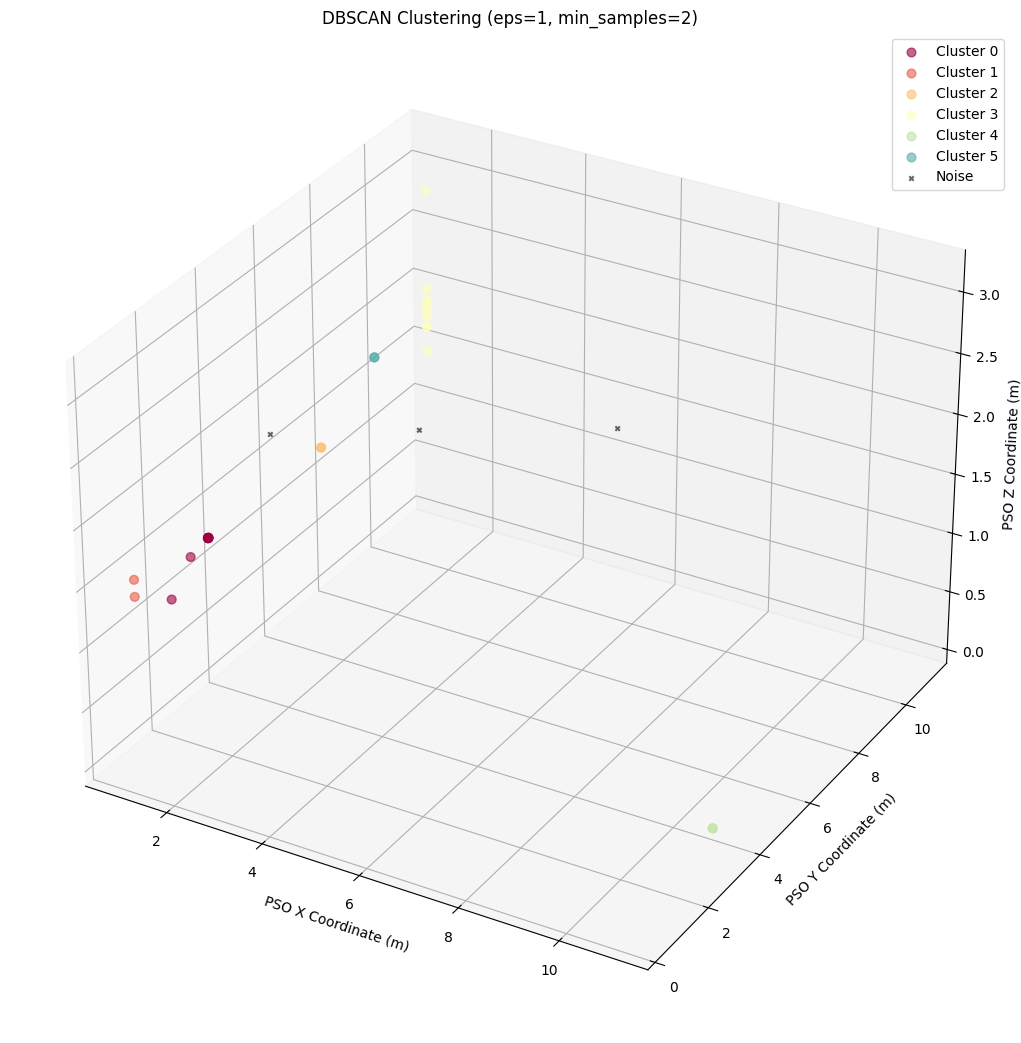

In [80]:
import matplotlib.pyplot as plt

print("Generating 3D Cluster Plot...")
    
fig = plt.figure(figsize=(15, 13))
ax = fig.add_subplot(111, projection='3d')

# Get unique labels
unique_labels = set(clusters)

# Define colors (using a colormap)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise, similar to unclassified points in paper figures
        col = [0, 0, 0, 1]
        label = "Noise"
        marker = 'x'
        size = 10
    else:
        label = f"Cluster {k}"
        marker = 'o'
        size = 40

    # Select data for this luster
    class_member_mask = (clusters == k)
    xyz = X[class_member_mask]
    
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], 
                c=[col], s=size, label=label, marker=marker, alpha=0.6)

ax.set_xlabel('PSO X Coordinate (m)')
ax.set_ylabel('PSO Y Coordinate (m)')
ax.set_zlabel('PSO Z Coordinate (m)')
ax.set_title(f'DBSCAN Clustering (eps={epsilon}, min_samples={min_samples})')
ax.legend()

plt.show()

In [81]:
# Calculate the mean PSO_X, PSO_Y, and PSO_Z for each cluster
pso_cluster_means = TDOA_results_df.groupby('cluster (PSO -> DBSCAN)')[['PSO_X', 'PSO_Y', 'PSO_Z']].mean()

# Display the results
print(pso_cluster_means)

                             PSO_X      PSO_Y     PSO_Z
cluster (PSO -> DBSCAN)                                
-1                        5.413333   3.476667  2.683333
 0                        1.000000   2.817273  1.372727
 1                        1.000000   0.500000  1.470000
 2                        1.000000   7.000000  1.400000
 3                        1.000000  11.000000  1.921111
 4                       11.000000   3.570000  0.100000
 5                        1.000000   9.005000  1.800000


In [82]:
def calculate_distance(arry1, arry2):
    return np.linalg.norm(arry1 - arry2)
print(calculate_distance(np.array([11,3.57,0.1]), np.array([9.2,3.5,2.8])))

3.245751068705054


In [11]:
'''
import PSO as pso
# PSO
temp1 = TDOA_results_df[['Actual_X', 'Actual_Y', 'Actual_Z']].to_numpy()
temp2 = TDOA_results_df[['TDOA_21', 'TDOA_31', 'TDOA_41']].to_numpy()
data_predict = np.concatenate((temp1, temp2), axis=1)
results = pso.pso_algorithm(data_predict)
'''

"\nimport PSO as pso\n# PSO\ntemp1 = TDOA_results_df[['Actual_X', 'Actual_Y', 'Actual_Z']].to_numpy()\ntemp2 = TDOA_results_df[['TDOA_21', 'TDOA_31', 'TDOA_41']].to_numpy()\ndata_predict = np.concatenate((temp1, temp2), axis=1)\nresults = pso.pso_algorithm(data_predict)\n"

In [12]:
'''
pso_results_df = pd.DataFrame(results)


pso_coordinates_df = pd.DataFrame(pso_results_df['estimated_location'].to_list(), columns=['PSO_X', 'PSO_Y', 'PSO_Z'])

pso_coordinates_df['PSO_oercentage_error'] = pso_results_df['percentage_error']
pso_coordinates_df['PSO_euclidean_distance'] = pso_results_df['euclidean_distance']

TDOA_results_df = pd.concat([TDOA_results_df, pso_coordinates_df], axis=1)

TDOA_results_df.to_csv('TDOA_Results.csv', index=False)
'''

"\npso_results_df = pd.DataFrame(results)\n\n\npso_coordinates_df = pd.DataFrame(pso_results_df['estimated_location'].to_list(), columns=['PSO_X', 'PSO_Y', 'PSO_Z'])\n\npso_coordinates_df['PSO_oercentage_error'] = pso_results_df['percentage_error']\npso_coordinates_df['PSO_euclidean_distance'] = pso_results_df['euclidean_distance']\n\nTDOA_results_df = pd.concat([TDOA_results_df, pso_coordinates_df], axis=1)\n\nTDOA_results_df.to_csv('TDOA_Results.csv', index=False)\n"

In [88]:
from sklearn.cluster import DBSCAN

epsilon = 1.5e-9
min_samples = 2

X = TDOA_results_df[['TDOA_21', 'TDOA_31', 'TDOA_41']].values

dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)

clusters = dbscan.fit_predict(X)

TDOA_results_df['cluster (DBSCAN -> PSO)'] = clusters

TDOA_results_df.to_csv('TDOA_Results_PCA.csv', index=False)

Generating 3D Cluster Plot...


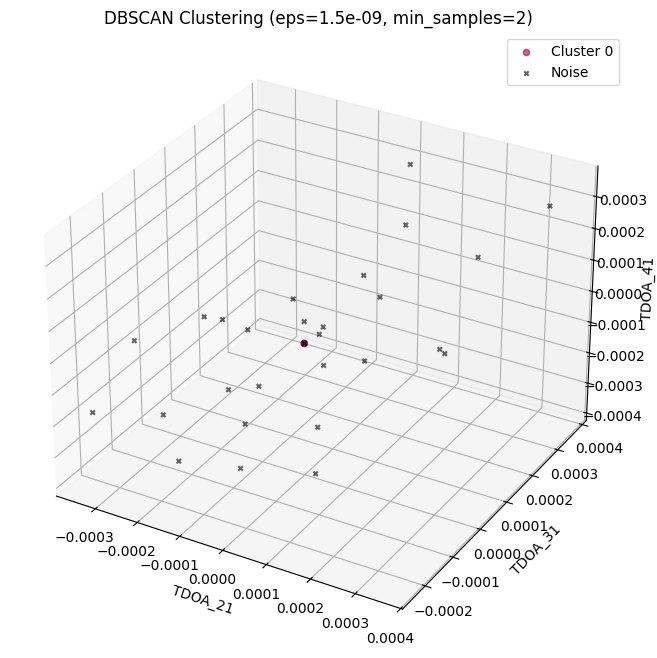

In [89]:
import matplotlib.pyplot as plt

print("Generating 3D Cluster Plot...")
    
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Get unique labels
unique_labels = set(clusters)

# Define colors (using a colormap)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise, similar to unclassified points in paper figures
        col = [0, 0, 0, 1]
        label = "Noise"
        marker = 'x'
        size = 10
    else:
        label = f"Cluster {k}"
        marker = 'o'
        size = 20

    # Select data for this cluster
    class_member_mask = (clusters == k)
    xyz = X[class_member_mask]
    
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], 
                c=[col], s=size, label=label, marker=marker, alpha=0.6)

ax.set_xlabel('TDOA_21')
ax.set_ylabel('TDOA_31')
ax.set_zlabel('TDOA_41')
ax.set_title(f'DBSCAN Clustering (eps={epsilon}, min_samples={min_samples})')
ax.legend()

plt.show()

In [ ]:
# Calculate mean TDOA and Actual coordinates for each cluster
cluster_means = TDOA_results_df[TDOA_results_df['cluster (DBSCAN -> PSO)'] != -1].groupby('cluster (DBSCAN -> PSO)').mean()

# Prepare data for PSO: Actual_X, Actual_Y, Actual_Z, TDOA_21, TDOA_31, TDOA_41
# The columns in cluster_means will be Group, TDOA_21, TDOA_31, TDOA_41, Actual_X, Actual_Y, Actual_Z
pso_input_data = cluster_means[['Actual_X', 'Actual_Y', 'Actual_Z', 'TDOA_21', 'TDOA_31', 'TDOA_41']].to_numpy()

print(f"Running PSO for {len(cluster_means)} clusters...")
import PSO as pso
cluster_pso_results = pso.pso_algorithm(pso_input_data)

# Convert results to DataFrame for display
cluster_pso_df = pd.DataFrame(cluster_pso_results)
# Add cluster ID back
cluster_pso_df['cluster'] = cluster_means.index.tolist()

print("\nPSO Results for Cluster Means:")
display(cluster_pso_df[['cluster', 'estimated_location', 'true_location', 'euclidean_distance', 'percentage_error']])


Running PSO for 1 clusters...
Convergence reached after 1093 iterations.

Results for dataset 1:
Estimated location: [np.float64(11.0), np.float64(3.56), np.float64(0.21)]
True location: [np.float64(2.9), np.float64(6.3), np.float64(5.4)]
Euclidean distance error: 10.004
Percentage error: 95.67%
Computation time: 31.42 seconds

PSO Results for Cluster Means:


,cluster,estimated_location,true_location,euclidean_distance,percentage_error
0,0,"[11.0, 3.56, 0.21]","[2.9, 6.3, 5.4]",10.004,95.67


In [90]:
def calculate_distance(arry1, arry2):
    return np.linalg.norm(arry1 - arry2)
print(calculate_distance(np.array([11,3.56,0.21]), np.array([9.2,3.5,2.8])))

3.1546315157241427
